In [191]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
%matplotlib inline
route_imp = 'best_model_gpa_imp.keras'

In [192]:
df_test = pd.read_csv("dataset/teen_test_clean.csv")
df_test.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,0.527299,0.088734,-1.051717,0.747859,-5.199338,0.03383,1.555322,-0.235783,0.853298,0,1,0,3.94
1,-1.461726,-0.501298,1.051717,-0.216904,-1.051717,-1.21526,-0.153041,0.815387,0.143756,1,0,1,2.45
2,0.527299,0.870846,0.619855,0.747859,-0.834427,0.03383,1.213649,-0.235783,-0.211015,1,1,0,3.59


In [193]:
df_train = pd.read_csv("dataset/teen_train_clean.csv")
df_train.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,-1.461726,-1.876359,0.870846,1.434200,0.101452,1.282919,-0.153041,0.815387,-0.211015,0,0,1,2.18
1,-0.467214,1.549706,-0.229884,1.807354,1.220640,1.282919,-1.519731,1.165777,0.143756,1,0,0,2.72
2,-0.964470,0.967422,0.714776,-0.714776,0.501298,0.033830,1.555322,-0.586173,-1.275328,0,0,1,3.81


In [194]:
y_test = df_test['target_academic_performance']
df_test = df_test.drop(columns=['target_academic_performance'])
X_test = df_test.copy()
y_test.head()

0    3.94
1    2.45
2    3.59
3    2.87
4    2.13
Name: target_academic_performance, dtype: float64

In [195]:
X_test.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,0.527299,0.088734,-1.051717,0.747859,-5.199338,0.03383,1.555322,-0.235783,0.853298,0,1,0
1,-1.461726,-0.501298,1.051717,-0.216904,-1.051717,-1.21526,-0.153041,0.815387,0.143756,1,0,1
2,0.527299,0.870846,0.619855,0.747859,-0.834427,0.03383,1.213649,-0.235783,-0.211015,1,1,0
3,-1.461726,-0.486994,-0.747859,-0.114185,1.220640,0.03383,-0.494713,1.165777,0.853298,1,0,1
4,0.527299,0.063341,-0.747859,0.889495,-0.037988,0.03383,-1.178058,-0.235783,0.143756,1,0,1


In [196]:
y_train = df_train['target_academic_performance']
df_train = df_train.drop(columns=['target_academic_performance'])
X_train = df_train.copy()
y_train.head()

0    2.18
1    2.72
2    3.81
3    2.89
4    2.60
Name: target_academic_performance, dtype: float64

In [197]:
X_train.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,-1.461726,-1.876359,0.870846,1.434200,0.101452,1.282919,-0.153041,0.815387,-0.211015,0,0,1
1,-0.467214,1.549706,-0.229884,1.807354,1.220640,1.282919,-1.519731,1.165777,0.143756,1,0,0
2,-0.964470,0.967422,0.714776,-0.714776,0.501298,0.033830,1.555322,-0.586173,-1.275328,0,0,1
3,-0.467214,1.304923,-0.269066,1.029957,1.593219,0.033830,0.530304,-0.936563,0.853298,1,0,0
4,-0.467214,0.714776,0.714776,-1.366707,-0.430727,1.282919,-0.494713,-0.586173,-1.275328,1,1,0


In [198]:
BATCH_SIZE = 16

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train.values, test_size=0.15
)

train_pipeline = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
train_pipeline = train_pipeline.shuffle(buffer_size=len(X_train_final)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.to_numpy(), y_test.to_numpy())).batch(BATCH_SIZE)

In [248]:
input_shape_dim = X_train_final.shape[1]
model_imp = tf.keras.Sequential([
   tf.keras.layers.Input(shape=(input_shape_dim,)),
    
    tf.keras.layers.Dense(128, activation='swish'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3), 
    
    tf.keras.layers.Dense(64, activation='swish'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(32, activation='swish'),    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(1)
])

In [249]:
checkpoint_callback_imp = ModelCheckpoint(
    filepath=route_imp,       
    monitor='val_mae',         
    save_best_only=True,        
    mode='min',                 
    verbose=1                   
)
early_stop = EarlyStopping(
    monitor='val_mae', 
    patience=16, 
    restore_best_weights=True
)
lr_reducer = ReduceLROnPlateau(
    monitor='val_mae', 
    factor=0.2,  
    patience=5,      
    min_lr=1e-5,     
    verbose=1
)

In [250]:
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)

model_imp.compile(
    optimizer=optimizer,             
    loss='mse',                   
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]       
)

In [251]:
history_imp = model_imp.fit(
    train_pipeline,
    epochs=100, 
    validation_data=val_dataset,
    callbacks=[checkpoint_callback_imp, lr_reducer, early_stop],
    verbose=1)

Epoch 1/100
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.8108 - mae: 2.8718 - rmse: 3.2866
Epoch 1: val_mae improved from None to 2.27977, saving model to best_model_gpa_imp.keras

Epoch 1: finished saving model to best_model_gpa_imp.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 10.1397 - mae: 2.7749 - rmse: 3.1843 - val_loss: 5.5245 - val_mae: 2.2798 - val_rmse: 2.3504 - learning_rate: 0.0010
Epoch 2/100
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.0815 - mae: 2.4547 - rmse: 2.8421
Epoch 2: val_mae improved from 2.27977 to 1.79763, saving model to best_model_gpa_imp.keras

Epoch 2: finished saving model to best_model_gpa_imp.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.4895 - mae: 2.3690 - rmse: 2.7367 - val_loss: 3.5756 - val_mae: 1.7976 - val_rmse: 1.8909 - learning_rate: 0.0010
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.8147 - mae: 2.0596 - rmse: 2.4111
Epoch 3: val_mae improved from 1.79763 to 1.48138, saving model to best_model_gpa_im

In [246]:
test_loss, test_mae, test_rmse = model_imp.evaluate(test_dataset, verbose=1)

print(f"\nTest MSE (Loss): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.7086 - mae: 2.5064 - rmse: 2.5901

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9120 - mae: 2.5674 - rmse: 2.6291

Test MSE (Loss): 6.9120
Test MAE: 2.5674
Test RMSE: 2.6291


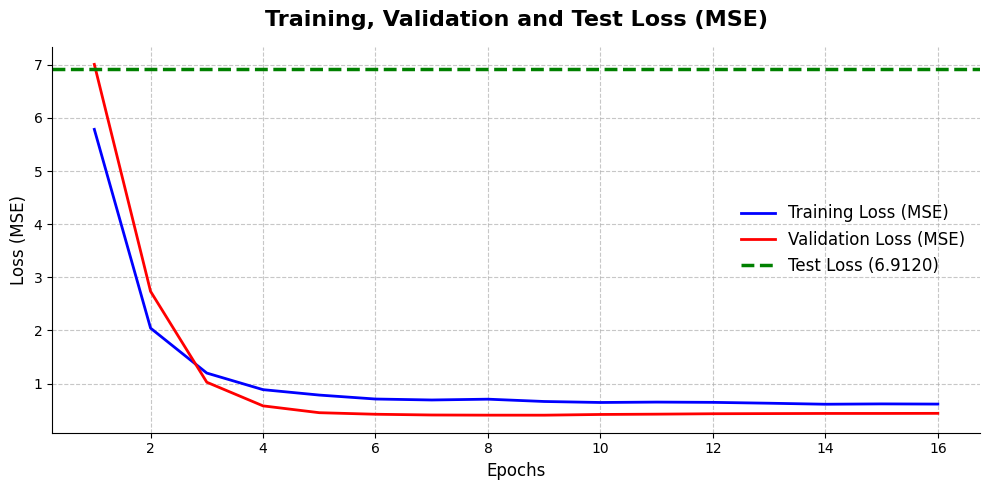

In [247]:
epochs = range(1, len(history_imp.history['loss']) + 1)
train_loss = history_imp.history['loss']
val_loss = history_imp.history['val_loss']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_loss, 'b-', label='Training Loss (MSE)', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss (MSE)', linewidth=2)
plt.axhline(y=test_loss, color='g', linestyle='--', label=f'Test Loss ({test_loss:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test Loss (MSE)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

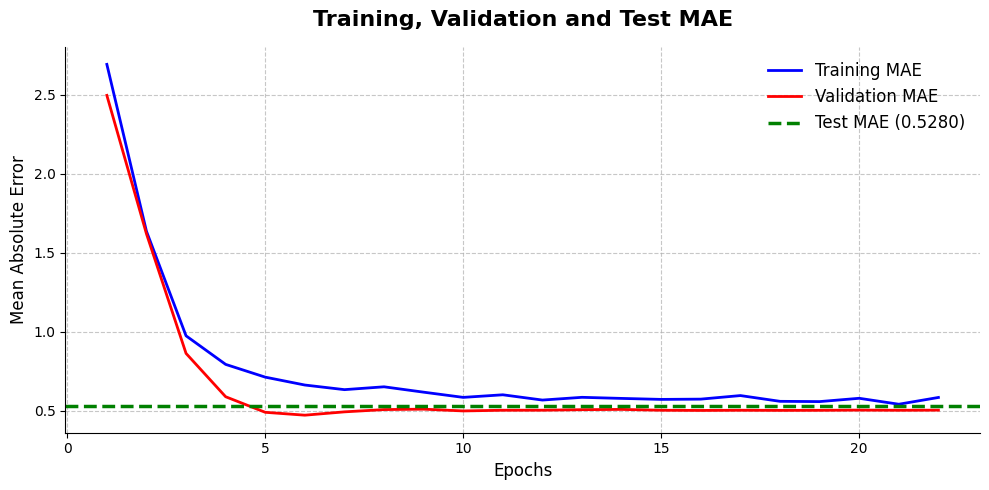

In [240]:
epochs = range(1, len(history_imp.history['mae']) + 1)
train_mae = history_imp.history['mae']
val_mae = history_imp.history['val_mae']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_mae, 'b-', label='Training MAE', linewidth=2)
plt.plot(epochs, val_mae, 'r-', label='Validation MAE', linewidth=2)
plt.axhline(y=test_mae, color='g', linestyle='--', label=f'Test MAE ({test_mae:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test MAE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

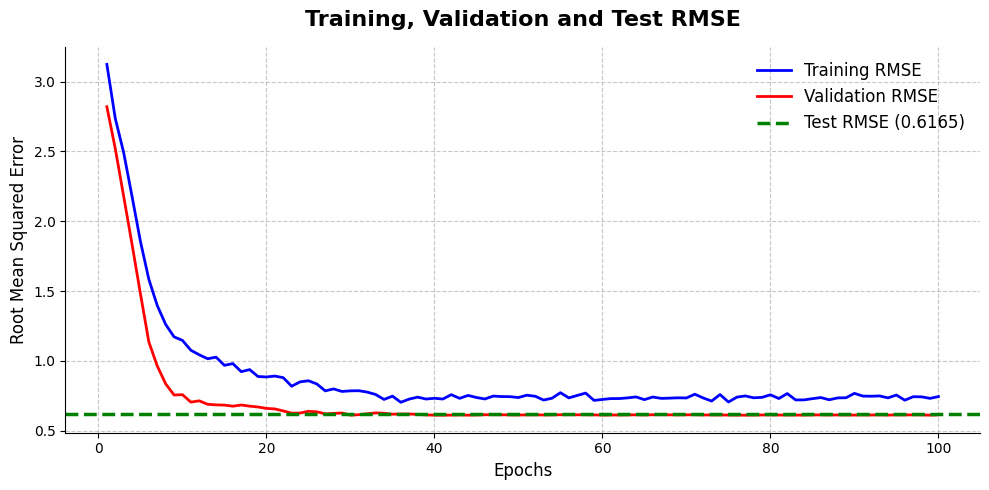

In [206]:
epochs = range(1, len(history_imp.history['rmse']) + 1)
train_rmse = history_imp.history['rmse']
val_rmse = history_imp.history['val_rmse']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_rmse, 'b-', label='Training RMSE', linewidth=2)
plt.plot(epochs, val_rmse, 'r-', label='Validation RMSE', linewidth=2)

plt.axhline(y=test_rmse, color='g', linestyle='--', label=f'Test RMSE ({test_rmse:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test RMSE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Root Mean Squared Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [207]:
final_train_loss = history_imp.history['loss'][-1]
final_val_loss = history_imp.history['val_loss'][-1]

final_train_mae = history_imp.history['mae'][-1]
final_val_mae = history_imp.history['val_mae'][-1]

final_train_rmse = history_imp.history['rmse'][-1]
final_val_rmse = history_imp.history['val_rmse'][-1]

data = {
    'Métrica': ['MSE (Loss)', 'MAE', 'RMSE'],
    'Train': [final_train_loss, final_train_mae, final_train_rmse],
    'Validation': [final_val_loss, final_val_mae, final_val_rmse],
    'Test': [test_loss, test_mae, test_rmse]
}

df_metrics = pd.DataFrame(data).round(4)
df_metrics

,Métrica,Train,Validation,Test
0,MSE (Loss),0.5537,0.3763,0.3800
1,MAE,0.6064,0.5243,0.5227
2,RMSE,0.7441,0.6134,0.6165
